### Ejercicio - 1
Recorta el punto de interés de la **Image2.png** tal cual se muestra en la figura, guarda la imagen recortada en tu disco local, y muestra la imagen original y la recortada con axis (imagen a colores).

![Image2.png](Image2.png)

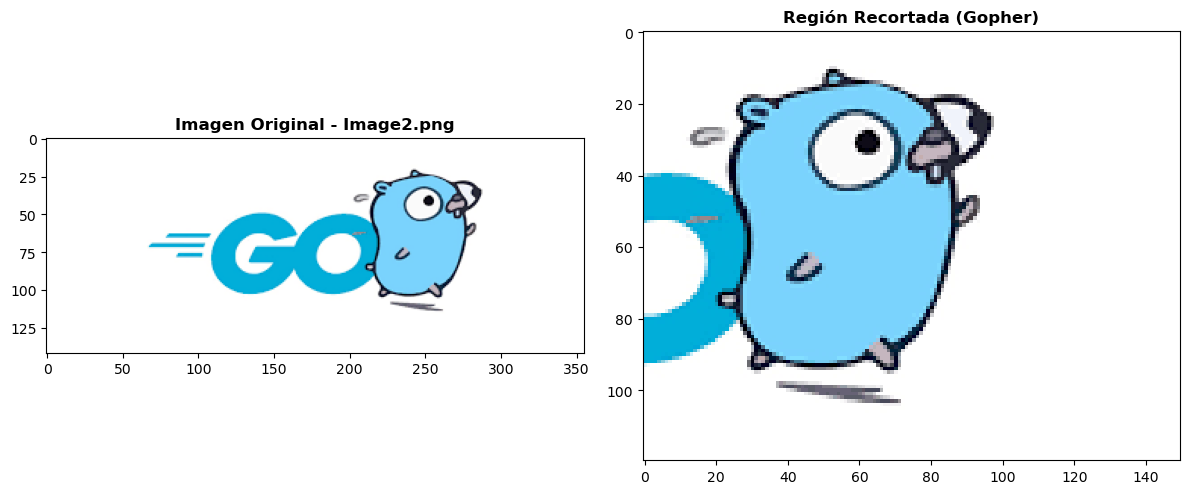

Imagen original: (142, 355, 3)
Imagen recortada: (120, 150, 3)
Imagen recortada guardada como 'Image2_recortada.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Cargar imagen original    
imagen = cv2.imread('Image2.png')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

# Definir región de interés (el gopher de Go)
# Coordenadas: y1:y2, x1:x2
roi = imagen_rgb[10:130, 190:340]

# Guardar imagen recortada
cv2.imwrite('Image2_recortada.png', cv2.cvtColor(roi, cv2.COLOR_RGB2BGR))

# Mostrar imagen original y recortada
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Imagen Original - Image2.png', fontsize=12, fontweight='bold')

axes[1].imshow(roi)
axes[1].set_title('Región Recortada (Gopher)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Imagen original: {imagen.shape}")
print(f"Imagen recortada: {roi.shape}")
print("Imagen recortada guardada como 'Image2_recortada.png'")

### Me dio cosa hacer uso de la imagen original y recorte una que tenia a mano 

### Ejercicio - 2
Genera un degradado lineal a colores (debe coincidir con los mismos colores del espectro visible). De **rojo** desde abajo hasta llegar a **violeta** arriba. Se genera una imagen de 256x256 px con transición suave a través del espectro HSV.

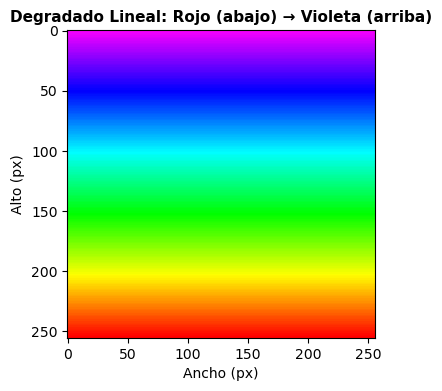

Imagen generada: (256, 256, 3)
Guardada como 'degradado_colores.png'


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
j
alto, ancho = 256, 256

# Crear imagen en espacio HSV
# H: 0 (rojo) abajo -> 150 (violeta) arriba en escala OpenCV (0-179)
# S y V a máximo para colores puros
hsv = np.zeros((alto, ancho, 3), dtype=np.uint8)

# Generar gradiente de Hue de abajo (rojo=0) a arriba (violeta=150)
for y in range(alto):
    # Fila 0 = arriba (violeta=150), fila 255 = abajo (rojo=0)
    hue = int(150 * (1 - y / (alto - 1)))
    hsv[y, :, 0] = hue       # Hue
    hsv[y, :, 1] = 255       # Saturación máxima
    hsv[y, :, 2] = 255       # Valor máximo

# Convertir HSV -> BGR -> RGB para visualización
degradado_bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
degradado_rgb = cv2.cvtColor(degradado_bgr, cv2.COLOR_BGR2RGB)

# Guardar imagen
cv2.imwrite('degradado_colores.png', degradado_bgr)

# Mostrar resultado
plt.figure(figsize=(4, 6))
plt.imshow(degradado_rgb)
plt.title('Degradado Lineal: Rojo (abajo) → Violeta (arriba)', fontsize=11, fontweight='bold')
plt.xlabel('Ancho (px)')
plt.ylabel('Alto (px)')
plt.tight_layout()
plt.show()

print(f"Imagen generada: {degradado_bgr.shape}")
print("Guardada como 'degradado_colores.png'")

### Ejercicio 3
Genera una imagen semejante a un **tablero de ajedrez** tomando en cuenta que cada casilla debe medir **100x100 px**. El tablero estándar es de 8x8 casillas (800x800 px total).

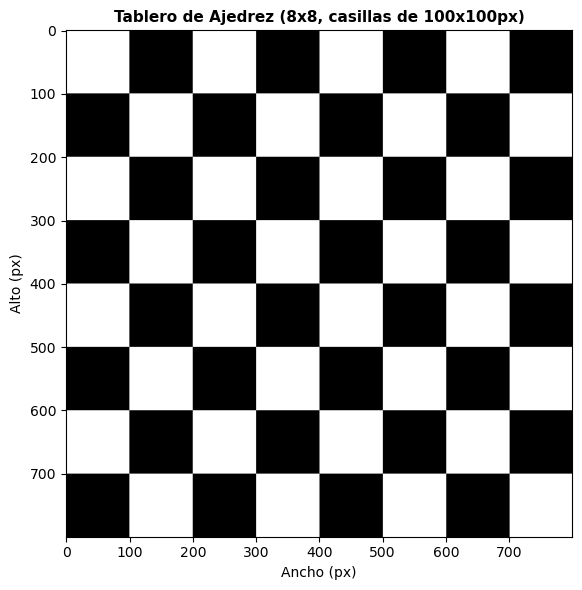

Tablero generado: (800, 800)
Guardado como 'tablero_ajedrez.png'


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

casilla = 100  # Tamaño de cada casilla en px
n_casillas = 8  # Tablero 8x8
tam = casilla * n_casillas  # 800x800 px

# Crear tablero usando operaciones vectorizadas
tablero = np.zeros((tam, tam), dtype=np.uint8)

for fila in range(n_casillas):
    for col in range(n_casillas):
        if (fila + col) % 2 == 0:
            y1, y2 = fila * casilla, (fila + 1) * casilla
            x1, x2 = col * casilla, (col + 1) * casilla
            tablero[y1:y2, x1:x2] = 255

# Guardar imagen
cv2.imwrite('tablero_ajedrez.png', tablero)

# Mostrar resultado
plt.figure(figsize=(6, 6))
plt.imshow(tablero, cmap='gray', vmin=0, vmax=255)
plt.title(f'Tablero de Ajedrez ({n_casillas}x{n_casillas}, casillas de {casilla}x{casilla}px)',
          fontsize=11, fontweight='bold')
plt.xlabel('Ancho (px)')
plt.ylabel('Alto (px)')
plt.tight_layout()
plt.show()

print(f"Tablero generado: {tablero.shape}")
print("Guardado como 'tablero_ajedrez.png'")

### Ejercicio - 4
Tomando en cuenta el resultado del **Ejercicio 2** (degradado de colores), aplica:
1. **Posterización** (reducción de niveles de color)
2. **Solarización** (inversión parcial de tonos)
3. Todas las **paletas de falso color** (colormaps) de OpenCV

Cada resultado debe guardarse en disco.

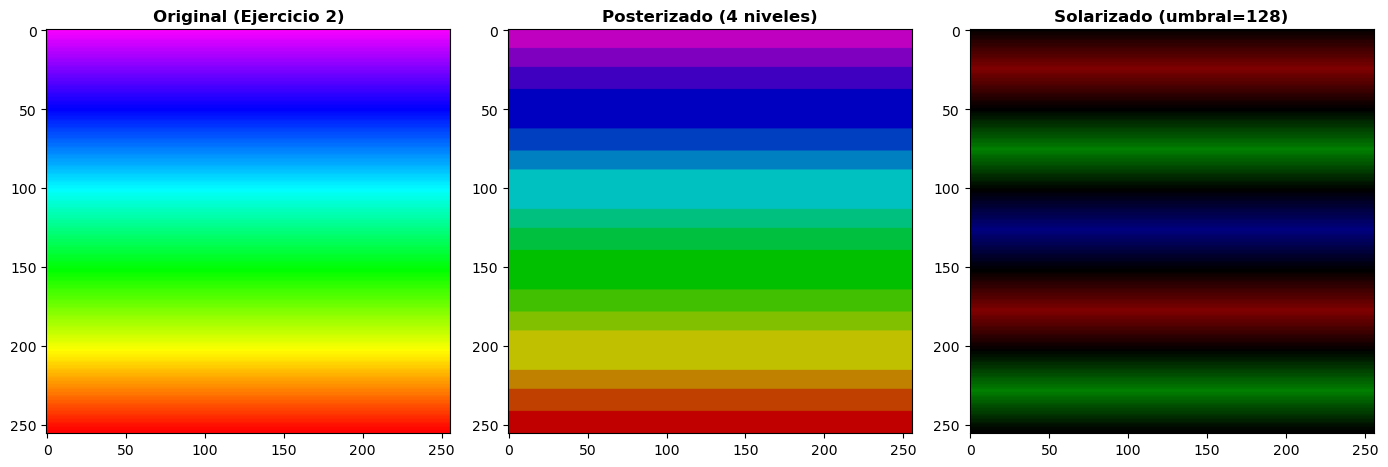

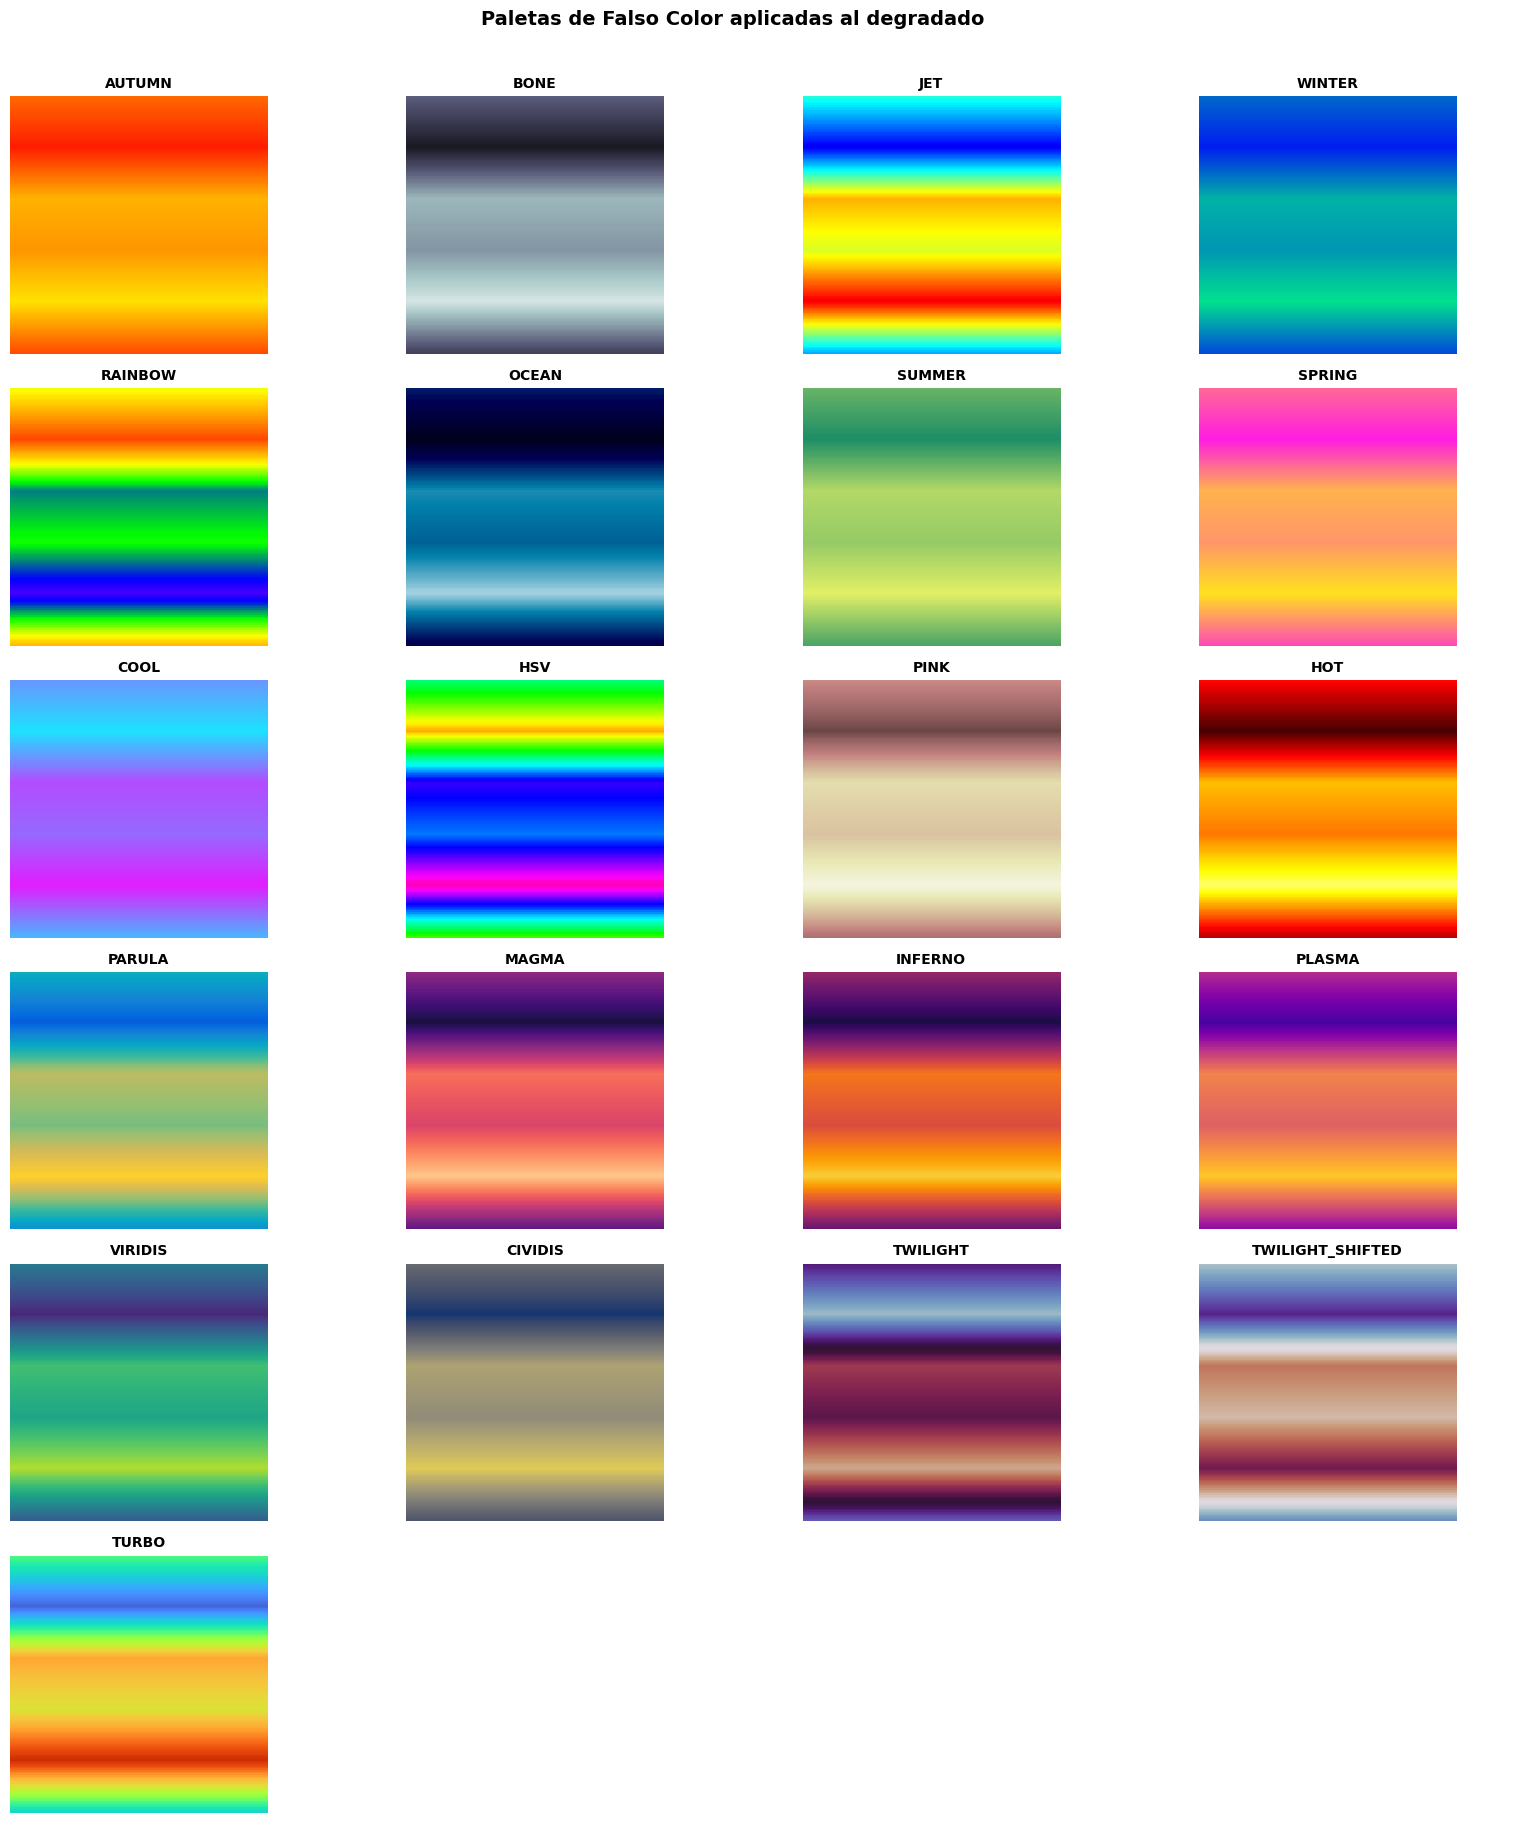

Total de imágenes guardadas: 23 (posterizado + solarizado + 21 paletas)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Cargar degradado del ejercicio 2
degradado = cv2.imread('degradado_colores.png')
degradado_rgb = cv2.cvtColor(degradado, cv2.COLOR_BGR2RGB)

# ========== 1. POSTERIZACIÓN ==========
# Reducir niveles de color (4 niveles por canal)
niveles = 4
factor = 256 // niveles
posterizado = (degradado // factor) * factor
posterizado_rgb = cv2.cvtColor(posterizado, cv2.COLOR_BGR2RGB)
cv2.imwrite('ej4_posterizado.png', posterizado)

# ========== 2. SOLARIZACIÓN ==========
# Invertir píxeles con valor > 128
umbral = 128
solarizado = degradado.copy()
solarizado[solarizado > umbral] = 255 - solarizado[solarizado > umbral]
solarizado_rgb = cv2.cvtColor(solarizado, cv2.COLOR_BGR2RGB)
cv2.imwrite('ej4_solarizado.png', solarizado)

# Mostrar posterización y solarización
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(degradado_rgb)
axes[0].set_title('Original (Ejercicio 2)', fontweight='bold')
axes[1].imshow(posterizado_rgb)
axes[1].set_title(f'Posterizado ({niveles} niveles)', fontweight='bold')
axes[2].imshow(solarizado_rgb)
axes[2].set_title(f'Solarizado (umbral={umbral})', fontweight='bold')
plt.tight_layout()
plt.show()

# ========== 3. PALETAS DE FALSO COLOR ==========
# Convertir a escala de grises para aplicar colormaps
degradado_gris = cv2.cvtColor(degradado, cv2.COLOR_BGR2GRAY)

# Todas las paletas de falso color de OpenCV
colormaps = {
    'AUTUMN': cv2.COLORMAP_AUTUMN,
    'BONE': cv2.COLORMAP_BONE,
    'JET': cv2.COLORMAP_JET,
    'WINTER': cv2.COLORMAP_WINTER,
    'RAINBOW': cv2.COLORMAP_RAINBOW,
    'OCEAN': cv2.COLORMAP_OCEAN,
    'SUMMER': cv2.COLORMAP_SUMMER,
    'SPRING': cv2.COLORMAP_SPRING,
    'COOL': cv2.COLORMAP_COOL,
    'HSV': cv2.COLORMAP_HSV,
    'PINK': cv2.COLORMAP_PINK,
    'HOT': cv2.COLORMAP_HOT,
    'PARULA': cv2.COLORMAP_PARULA,
    'MAGMA': cv2.COLORMAP_MAGMA,
    'INFERNO': cv2.COLORMAP_INFERNO,
    'PLASMA': cv2.COLORMAP_PLASMA,
    'VIRIDIS': cv2.COLORMAP_VIRIDIS,
    'CIVIDIS': cv2.COLORMAP_CIVIDIS,
    'TWILIGHT': cv2.COLORMAP_TWILIGHT,
    'TWILIGHT_SHIFTED': cv2.COLORMAP_TWILIGHT_SHIFTED,
    'TURBO': cv2.COLORMAP_TURBO,
}

n_maps = len(colormaps)
cols = 4
filas = (n_maps + cols - 1) // cols

fig, axes = plt.subplots(filas, cols, figsize=(16, filas * 3))
axes = axes.flatten()

for i, (nombre, cmap) in enumerate(colormaps.items()):
    falso_color = cv2.applyColorMap(degradado_gris, cmap)
    falso_color_rgb = cv2.cvtColor(falso_color, cv2.COLOR_BGR2RGB)
    
    # Guardar cada resultado
    cv2.imwrite(f'ej4_falsocolor_{nombre.lower()}.png', falso_color)
    
    axes[i].imshow(falso_color_rgb)
    axes[i].set_title(nombre, fontweight='bold', fontsize=10)
    axes[i].axis('off')

# Ocultar ejes vacíos
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Paletas de Falso Color aplicadas al degradado', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Total de imágenes guardadas: {n_maps + 2} (posterizado + solarizado + {n_maps} paletas)")

### Ejercicio 5
Tomando en cuenta la **Image2.png**, aplica un **degradado lineal** sobre ella: de **derecha** (tono más oscuro) a **izquierda** (parte más clara). Se utiliza una máscara de gradiente horizontal multiplicada sobre la imagen.

![Image2.png](Image2.png)

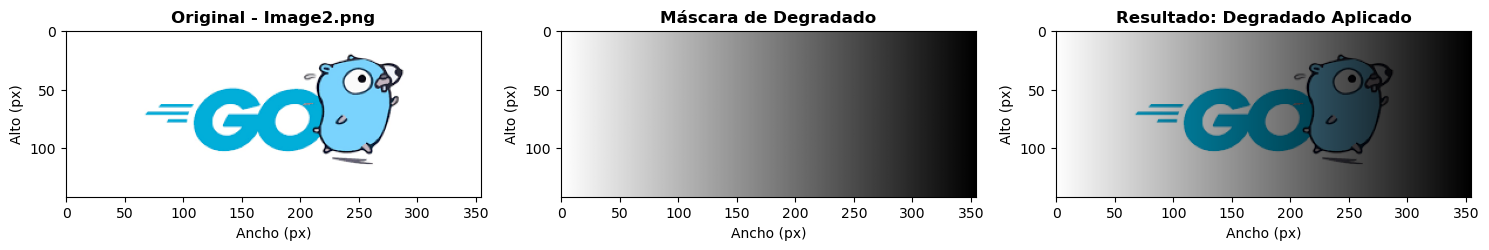

Imagen con degradado: (142, 355, 3)
Guardada como 'ej5_degradado_lineal.png'


In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Cargar imagen
imagen = cv2.imread('Image2.png')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
alto, ancho = imagen.shape[:2]

# Crear máscara de degradado horizontal
# Izquierda (claro, factor=1.0) -> Derecha (oscuro, factor=0.0)
gradiente = np.linspace(1.0, 0.0, ancho).reshape(1, ancho)
# Expandir a todas las filas
mascara = np.repeat(gradiente, alto, axis=0)
# Expandir a 3 canales
mascara_3ch = np.stack([mascara] * 3, axis=2)

# Aplicar degradado multiplicativo
resultado = (imagen_rgb.astype(np.float64) * mascara_3ch).astype(np.uint8)

# Guardar resultado
cv2.imwrite('ej5_degradado_lineal.png', cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR))

# Mostrar comparación
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Original - Image2.png', fontweight='bold')

axes[1].imshow(mascara, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Máscara de Degradado', fontweight='bold')

axes[2].imshow(resultado)
axes[2].set_title('Resultado: Degradado Aplicado', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Ancho (px)')
    ax.set_ylabel('Alto (px)')

plt.tight_layout()
plt.show()

print(f"Imagen con degradado: {resultado.shape}")
print("Guardada como 'ej5_degradado_lineal.png'")

### Ejercicio - 6
Elabora una **imagen original de calle cyberpunk en perspectiva** usando únicamente cuadrados de colores con estilo **neón nocturno**, posterior a ello se aplica el **filtro Bayer** en todas sus combinaciones:
- **RGGB** (BG2BGR)
- **BGGR** (RG2BGR)
- **GRBG** (GB2BGR)
- **GBRG** (GR2BGR)

**Elementos de la escena con perspectiva (punto de fuga central):**
- Calle en perspectiva con punto de fuga al centro-superior
- Edificios a ambos lados que convergen hacia el fondo
- Letreros neón (HOTEL, SNACK, etc.) con glow
- Vehículos en la calle
- Acera con personas/figuras
- Puentes/estructuras aéreas
- Reflejos neón en el asfalto mojado
- Glow global sobre elementos brillantes

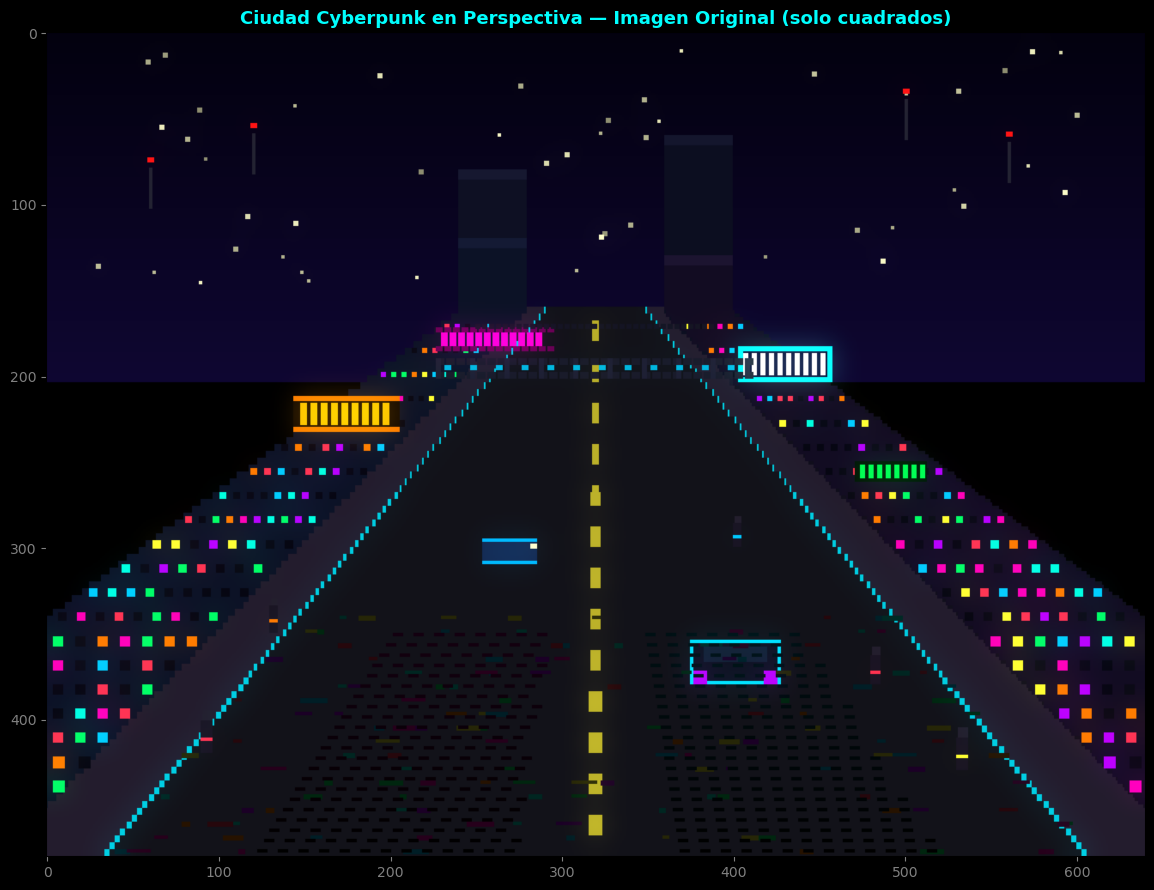

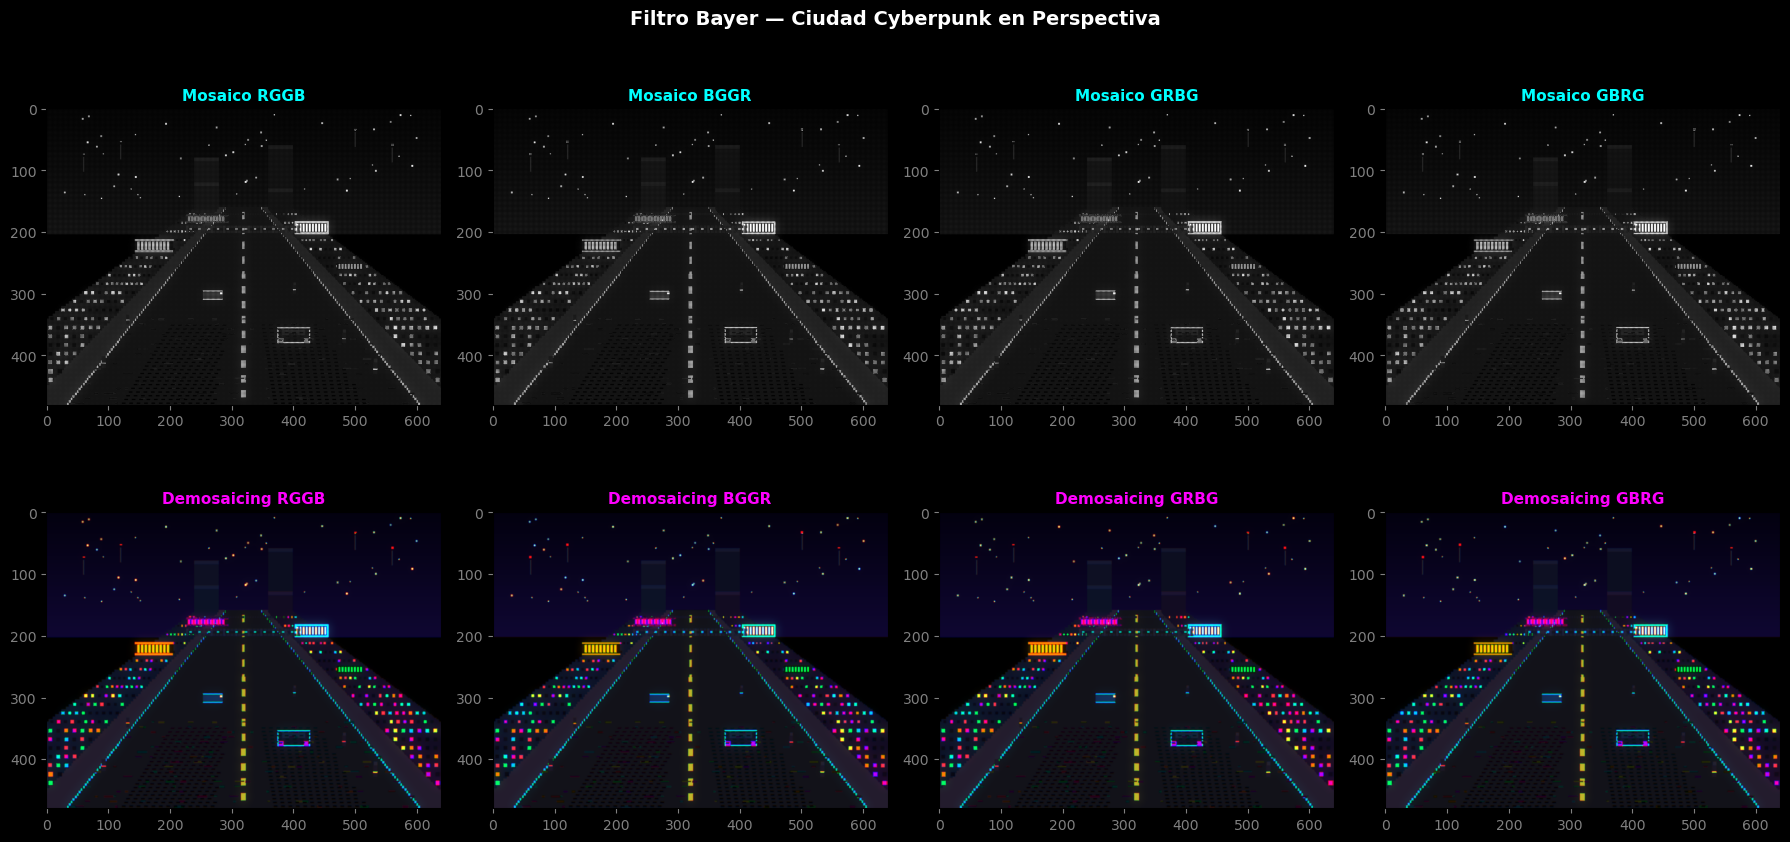

Imágenes guardadas: ciudad cyberpunk + 4 mosaicos + 4 reconstrucciones


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ========== CIUDAD CYBERPUNK EN PERSPECTIVA (solo cuadrados) ==========
W, H = 640, 480
city = np.zeros((H, W, 3), dtype=np.uint8)

# Punto de fuga
VX, VY = W // 2, 160

# --- Función auxiliar: dibujar cuadrado ---
def sq(y1, x1, y2, x2, color):
    """Dibuja un cuadrado/rectángulo con clipping"""
    y1, y2 = max(0, int(y1)), min(H, int(y2))
    x1, x2 = max(0, int(x1)), min(W, int(x2))
    if y1 < y2 and x1 < x2:
        city[y1:y2, x1:x2] = color

# ==================== CIELO ====================
for y in range(0, VY + 40, 6):
    t = y / (VY + 40)
    sq(y, 0, y+6, W, [int(3 + t*12), int(1 + t*6), int(15 + t*35)])

# Estrellas
np.random.seed(2077)
for _ in range(50):
    sx, sy = np.random.randint(20, W-20), np.random.randint(5, VY-10)
    s = np.random.choice([2, 3])
    b = np.random.randint(140, 255)
    sq(sy, sx, sy+s, sx+s, [b, b, int(b*0.8)])

# ==================== CALLE (perspectiva) ====================
# El suelo se expande desde el punto de fuga hacia abajo
for y in range(VY, H, 4):
    t = (y - VY) / (H - VY)  # 0 en punto de fuga, 1 en base
    # Ancho de la calle se expande
    road_half = int(30 + t * 260)
    left_road = VX - road_half
    right_road = VX + road_half

    # Aceras (más claras)
    sidewalk_w = int(10 + t * 50)
    sq(y, left_road - sidewalk_w, y+4, left_road, [35, 28, 45])
    sq(y, right_road, y+4, right_road + sidewalk_w, [35, 28, 45])

    # Asfalto
    sq(y, left_road, y+4, right_road, [18, 18, 25])

    # Línea central discontinua
    if (y // 12) % 2 == 0:
        lw = max(1, int(2 + t * 3))
        sq(y, VX - lw, y+4, VX + lw, [180, 170, 40])

    # Líneas laterales de la calle (cyan neón)
    line_w = max(1, int(1 + t * 3))
    sq(y, left_road, y+4, left_road + line_w, [0, 200, 220])
    sq(y, right_road - line_w, y+4, right_road, [0, 200, 220])

# ==================== EDIFICIOS IZQUIERDA ====================
# Los edificios se dibujan en franjas que convergen al punto de fuga
def draw_building_left(depth_start, depth_end, facade_color, roof_color, windows):
    """Edificio en el lado izquierdo con perspectiva"""
    for y in range(max(0, depth_start), min(H, depth_end), 4):
        t = (y - VY) / (H - VY) if y > VY else 0
        road_half = int(30 + t * 260)
        sidewalk_w = int(10 + t * 50)
        bld_right = VX - road_half - sidewalk_w
        bld_left = max(0, bld_right - int(40 + t * 120))
        sq(y, bld_left, y+4, bld_right, facade_color)
    # Techo
    y = depth_start
    t = max(0, (y - VY) / (H - VY)) if y > VY else 0
    road_half = int(30 + t * 260)
    sidewalk_w = int(10 + t * 50)
    bld_right = VX - road_half - sidewalk_w
    bld_left = max(0, bld_right - int(40 + t * 120))
    sq(depth_start, bld_left, depth_start + 6, bld_right, roof_color)

def draw_building_right(depth_start, depth_end, facade_color, roof_color, windows):
    """Edificio en el lado derecho con perspectiva"""
    for y in range(max(0, depth_start), min(H, depth_end), 4):
        t = (y - VY) / (H - VY) if y > VY else 0
        road_half = int(30 + t * 260)
        sidewalk_w = int(10 + t * 50)
        bld_left = VX + road_half + sidewalk_w
        bld_right = min(W, bld_left + int(40 + t * 120))
        sq(y, bld_left, y+4, bld_right, facade_color)
    # Techo
    y = depth_start
    t = max(0, (y - VY) / (H - VY)) if y > VY else 0
    road_half = int(30 + t * 260)
    sidewalk_w = int(10 + t * 50)
    bld_left = VX + road_half + sidewalk_w
    bld_right = min(W, bld_left + int(40 + t * 120))
    sq(depth_start, bld_left, depth_start + 6, bld_right, roof_color)

# Edificios lejanos (fondo)
draw_building_left(80, H, (14, 16, 35), (22, 24, 48), True)
draw_building_right(60, H, (12, 14, 32), (20, 22, 45), True)

# Edificios cercanos (superpuestos, frente)
draw_building_left(180, H, (10, 12, 30), (18, 20, 42), True)
draw_building_right(200, H, (16, 14, 28), (24, 22, 40), True)

# Edificios extra (capas de profundidad)
draw_building_left(120, H, (12, 18, 38), (20, 26, 52), True)
draw_building_right(130, H, (18, 12, 34), (28, 20, 48), True)

# ==================== VENTANAS NEÓN ====================
colores_neon = [
    (255, 0, 180), (0, 255, 220), (255, 120, 0), (180, 0, 255),
    (0, 200, 255), (255, 255, 50), (255, 50, 80), (0, 255, 100),
    (8, 8, 20), (8, 8, 20), (10, 10, 22), (6, 6, 18),  # Apagadas
]

np.random.seed(42)
# Ventanas izquierda
for y in range(VY + 10, H - 40, 14):
    t = (y - VY) / (H - VY)
    road_half = int(30 + t * 260)
    sidewalk_w = int(10 + t * 50)
    bld_right = VX - road_half - sidewalk_w
    bld_left = max(0, bld_right - int(40 + t * 120))
    win_size = max(3, int(3 + t * 5))
    for wx in range(bld_left + 4, bld_right - win_size, int(win_size * 2.2)):
        ci = np.random.randint(0, len(colores_neon))
        sq(y, wx, y + win_size, wx + win_size, colores_neon[ci])

# Ventanas derecha
for y in range(VY + 10, H - 40, 14):
    t = (y - VY) / (H - VY)
    road_half = int(30 + t * 260)
    sidewalk_w = int(10 + t * 50)
    bld_left = VX + road_half + sidewalk_w
    bld_right = min(W, bld_left + int(40 + t * 120))
    win_size = max(3, int(3 + t * 5))
    for wx in range(bld_left + 4, bld_right - win_size, int(win_size * 2.2)):
        ci = np.random.randint(0, len(colores_neon))
        sq(y, wx, y + win_size, wx + win_size, colores_neon[ci])

# ==================== LETREROS NEÓN ====================
# HOTEL (lado derecho, grande, arriba)
sign_y = 200
t_s = (sign_y - VY) / (H - VY)
sign_x = VX + int(30 + t_s * 260) + int(10 + t_s * 50) + 5
sign_w, sign_h = int(50 + t_s * 40), int(12 + t_s * 8)
# Fondo letrero
sq(sign_y - sign_h - 4, sign_x, sign_y + 4, sign_x + sign_w, [0, 0, 40])
# Texto neón (bloques horizontales que simulan "HOTEL")
for bx in range(sign_x + 3, sign_x + sign_w - 3, 5):
    sq(sign_y - sign_h, bx, sign_y, bx + 3, [255, 255, 255])
# Marco neón cyan
sq(sign_y - sign_h - 4, sign_x, sign_y - sign_h - 1, sign_x + sign_w, [0, 255, 240])
sq(sign_y + 1, sign_x, sign_y + 4, sign_x + sign_w, [0, 255, 240])
sq(sign_y - sign_h - 4, sign_x, sign_y + 4, sign_x + 3, [0, 255, 240])
sq(sign_y - sign_h - 4, sign_x + sign_w - 3, sign_y + 4, sign_x + sign_w, [0, 255, 240])

# SNACK (lado izquierdo, naranja)
sign_y2 = 230
t_s2 = (sign_y2 - VY) / (H - VY)
sign_x2 = VX - int(30 + t_s2 * 260) - int(10 + t_s2 * 50) - int(60 + t_s2 * 50)
sign_w2, sign_h2 = int(55 + t_s2 * 35), int(14 + t_s2 * 6)
sq(sign_y2 - sign_h2 - 3, sign_x2, sign_y2 + 3, sign_x2 + sign_w2, [15, 8, 0])
for bx in range(sign_x2 + 4, sign_x2 + sign_w2 - 4, 6):
    sq(sign_y2 - sign_h2 + 1, bx, sign_y2 - 1, bx + 4, [255, 180, 0])
sq(sign_y2 - sign_h2 - 3, sign_x2, sign_y2 - sign_h2, sign_x2 + sign_w2, [255, 120, 0])
sq(sign_y2, sign_x2, sign_y2 + 3, sign_x2 + sign_w2, [255, 120, 0])

# Letrero magenta flotante (arriba, centro-izquierda)
for bx in range(VX - 90, VX - 30, 5):
    sq(VY + 15, bx, VY + 23, bx + 4, [255, 0, 200])
# Glow
for bx in range(VX - 93, VX - 27, 5):
    sq(VY + 12, bx, VY + 15, bx + 4, [100, 0, 80])
    sq(VY + 23, bx, VY + 26, bx + 4, [100, 0, 80])

# Letrero verde (lado derecho, nivel medio)
sign_y3 = 260
t_s3 = (sign_y3 - VY) / (H - VY)
sign_x3 = VX + int(30 + t_s3 * 260) + int(10 + t_s3 * 50) + 15
sign_w3 = int(35 + t_s3 * 25)
sq(sign_y3 - 10, sign_x3, sign_y3 + 2, sign_x3 + sign_w3, [0, 20, 5])
for bx in range(sign_x3 + 3, sign_x3 + sign_w3 - 3, 5):
    sq(sign_y3 - 8, bx, sign_y3, bx + 3, [0, 255, 80])

# ==================== PUENTE/ESTRUCTURA AÉREA ====================
# Estructura horizontal que cruza la calle (perspectiva)
bridge_y = VY + 30
t_b = (bridge_y - VY) / (H - VY)
road_half_b = int(30 + t_b * 260)
sw_b = int(10 + t_b * 50)
left_b = VX - road_half_b - sw_b - int(20 + t_b * 60)
right_b = VX + road_half_b + sw_b + int(20 + t_b * 60)
# Vigas horizontales
for bx in range(left_b, right_b, 6):
    sq(bridge_y, bx, bridge_y + 4, bx + 5, [25, 25, 40])
    sq(bridge_y + 8, bx, bridge_y + 12, bx + 5, [25, 25, 40])
# Vigas verticales (soportes)
for bx in range(left_b, right_b, 20):
    sq(bridge_y, bx, bridge_y + 12, bx + 3, [30, 30, 50])
# Luces en el puente
for bx in range(left_b + 5, right_b - 5, 15):
    sq(bridge_y + 4, bx, bridge_y + 7, bx + 4, [0, 180, 220])

# Segundo puente más atrás
bridge_y2 = VY + 10
t_b2 = max(0.01, (bridge_y2 - VY) / (H - VY))
road_half_b2 = int(30 + t_b2 * 260)
sw_b2 = int(10 + t_b2 * 50)
left_b2 = VX - road_half_b2 - sw_b2 - int(20 + t_b2 * 60)
right_b2 = VX + road_half_b2 + sw_b2 + int(20 + t_b2 * 60)
for bx in range(left_b2, right_b2, 4):
    sq(bridge_y2, bx, bridge_y2 + 3, bx + 3, [20, 20, 35])

# ==================== VEHÍCULOS ====================
# Coche 1 (cerca, lado derecho)
car_y = 380
t_c = (car_y - VY) / (H - VY)
car_x = VX + int(t_c * 80)
car_w, car_h = int(40 + t_c * 20), int(20 + t_c * 10)
# Carrocería
sq(car_y - car_h, car_x, car_y, car_x + car_w, [15, 15, 30])
# Contorno neón cyan
sq(car_y - car_h, car_x, car_y - car_h + 2, car_x + car_w, [0, 220, 255])
sq(car_y - 2, car_x, car_y, car_x + car_w, [0, 220, 255])
sq(car_y - car_h, car_x, car_y, car_x + 2, [0, 220, 255])
sq(car_y - car_h, car_x + car_w - 2, car_y, car_x + car_w, [0, 220, 255])
# Ventana
sq(car_y - car_h + 4, car_x + 8, car_y - car_h + car_h//2, car_x + car_w - 8, [20, 30, 50])
# Ruedas (cuadrados neón)
wh = max(4, car_h // 3)
sq(car_y - wh, car_x + 2, car_y, car_x + 2 + wh, [180, 0, 255])
sq(car_y - wh, car_x + car_w - 2 - wh, car_y, car_x + car_w - 2, [180, 0, 255])

# Coche 2 (más lejos, lado izquierdo)
car_y2 = 310
t_c2 = (car_y2 - VY) / (H - VY)
car_x2 = VX - int(t_c2 * 100) - 20
car_w2, car_h2 = int(25 + t_c2 * 15), int(12 + t_c2 * 8)
sq(car_y2 - car_h2, car_x2, car_y2, car_x2 + car_w2, [20, 40, 80])
sq(car_y2 - car_h2, car_x2, car_y2 - car_h2 + 2, car_x2 + car_w2, [0, 180, 255])
sq(car_y2 - 2, car_x2, car_y2, car_x2 + car_w2, [0, 180, 255])
# Luces delanteras
sq(car_y2 - car_h2 + 3, car_x2 + car_w2 - 4, car_y2 - car_h2 + 6, car_x2 + car_w2, [255, 255, 200])

# ==================== FIGURAS/PERSONAS (siluetas con cuadrados) ====================
np.random.seed(123)
personas = [(420, 90), (430, 530), (380, 480), (350, 130), (300, 400)]
for py, px in personas:
    t_p = (py - VY) / (H - VY)
    p_h = max(6, int(8 + t_p * 14))
    p_w = max(3, int(3 + t_p * 5))
    # Cuerpo
    sq(py - p_h, px, py, px + p_w, [25, 20, 35])
    # Cabeza
    head = max(2, p_w - 1)
    sq(py - p_h - head, px + 1, py - p_h, px + 1 + head, [35, 30, 45])
    # Detalle neón (ropa)
    accent = colores_neon[np.random.randint(0, 8)]
    sq(py - p_h//2, px, py - p_h//2 + 2, px + p_w, accent)

# ==================== REFLEJOS EN ASFALTO MOJADO ====================
np.random.seed(555)
for y in range(340, H, 8):
    t = (y - VY) / (H - VY)
    road_half = int(30 + t * 260)
    for _ in range(8):
        rx = VX + np.random.randint(-road_half, road_half)
        rw = np.random.randint(4, int(8 + t * 10))
        rh = np.random.randint(2, 4)
        ci = np.random.randint(0, 8)
        c = np.array(colores_neon[ci], dtype=np.float64) * 0.15
        sq(y, rx, y + rh, rx + rw, c.astype(np.uint8))

# More concentrated reflections under neon signs
for ry in range(350, H, 6):
    t_r = (ry - VY) / (H - VY)
    # Left side reflections (magenta/orange from signs)
    for rx in range(VX - int(t_r * 200), VX - int(t_r * 50), 12):
        sq(ry, rx, ry + 2, rx + 6, [int(50 * (1-t_r)), 0, int(40 * (1-t_r))])
    # Right side reflections (cyan from signs)
    for rx in range(VX + int(t_r * 50), VX + int(t_r * 200), 12):
        sq(ry, rx, ry + 2, rx + 6, [0, int(40 * (1-t_r)), int(50 * (1-t_r))])

# ==================== ANTENAS ====================
antenas = [(120, 80), (500, 60), (60, 100), (560, 85)]
for ax_p, ay_p in antenas:
    for i in range(8):
        sq(ay_p - i*3, ax_p, ay_p - i*3 + 3, ax_p + 2, [35, 35, 50])
    sq(ay_p - 27, ax_p - 1, ay_p - 24, ax_p + 3, [255, 20, 20])

# ==================== GLOW GLOBAL ====================
mascara_brillo = np.zeros_like(city)
bright = np.max(city, axis=2) > 100
mascara_brillo[bright] = city[bright]

glow = cv2.GaussianBlur(mascara_brillo.astype(np.float64), (0, 0), 8)
city_final = np.clip(city.astype(np.float64) + glow * 0.35, 0, 255).astype(np.uint8)

# Guardar
cv2.imwrite('ej6_ciudad_cyberpunk.png', cv2.cvtColor(city_final, cv2.COLOR_RGB2BGR))

# ========== MOSTRAR ==========
fig, ax = plt.subplots(1, 1, figsize=(12, 9))
fig.patch.set_facecolor('black')
ax.imshow(city_final)
ax.set_title('Ciudad Cyberpunk en Perspectiva — Imagen Original (solo cuadrados)',
             fontweight='bold', fontsize=13, color='cyan')
ax.set_facecolor('black')
ax.tick_params(colors='gray')
plt.tight_layout()
plt.show()

# ========== FILTRO BAYER ==========
def aplicar_bayer(img_rgb, patron):
    alto, ancho = img_rgb.shape[:2]
    R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]
    bayer = np.zeros((alto, ancho), dtype=np.uint8)
    y_par, y_impar = np.arange(0, alto, 2), np.arange(1, alto, 2)
    x_par, x_impar = np.arange(0, ancho, 2), np.arange(1, ancho, 2)
    canales = {
        'RGGB': (R, G, G, B), 'BGGR': (B, G, G, R),
        'GRBG': (G, R, B, G), 'GBRG': (G, B, R, G),
    }
    tl, tr, bl, br = canales[patron]
    bayer[np.ix_(y_par, x_par)]     = tl[np.ix_(y_par, x_par)]
    bayer[np.ix_(y_par, x_impar)]   = tr[np.ix_(y_par, x_impar)]
    bayer[np.ix_(y_impar, x_par)]   = bl[np.ix_(y_impar, x_par)]
    bayer[np.ix_(y_impar, x_impar)] = br[np.ix_(y_impar, x_impar)]
    return bayer

bayer_configs = [
    ('RGGB', cv2.COLOR_BAYER_BG2BGR), ('BGGR', cv2.COLOR_BAYER_RG2BGR),
    ('GRBG', cv2.COLOR_BAYER_GB2BGR), ('GBRG', cv2.COLOR_BAYER_GR2BGR),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor('black')

for i, (patron, demosaic_code) in enumerate(bayer_configs):
    bayer_img = aplicar_bayer(city_final, patron)
    reconstruida = cv2.cvtColor(bayer_img, demosaic_code)
    reconstruida_rgb = cv2.cvtColor(reconstruida, cv2.COLOR_BGR2RGB)
    cv2.imwrite(f'ej6_bayer_{patron}_mosaico.png', bayer_img)
    cv2.imwrite(f'ej6_bayer_{patron}_reconstruida.png', reconstruida)
    axes[0, i].imshow(bayer_img, cmap='gray')
    axes[0, i].set_title(f'Mosaico {patron}', fontweight='bold', fontsize=11, color='cyan')
    axes[0, i].set_facecolor('black')
    axes[1, i].imshow(reconstruida_rgb)
    axes[1, i].set_title(f'Demosaicing {patron}', fontweight='bold', fontsize=11, color='magenta')
    axes[1, i].set_facecolor('black')

for ax in axes.flatten():
    ax.tick_params(colors='gray')

fig.suptitle('Filtro Bayer — Ciudad Cyberpunk en Perspectiva', fontsize=14,
             fontweight='bold', color='white')
plt.tight_layout()
plt.show()

print(f"Imágenes guardadas: ciudad cyberpunk + {len(bayer_configs)} mosaicos + {len(bayer_configs)} reconstrucciones")